In [1]:
import tiktoken

# Load the tokenizer for GPT-4o
encoding = tiktoken.encoding_for_model("gpt-4o")
print(encoding.name)

system_message ="""
Perform Sentiment analysis of the review presented in the user message.
The result should be positive or negative. Do not justify your response
"""

# Encode the message into tokens
tokens = encoding.encode(system_message)
print(len(tokens))
print(tokens)

# Decode token by token
for token in tokens:
    print(encoding.decode_single_token_bytes(token=token), end="")

# Reusable function to count tokens
def num_tokens_from_string(string: str, encoding_name: str = "o200k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# Test the function
num_tokens_from_string("tiktoken is great!")

o200k_base
28
[198, 73751, 31712, 2581, 8450, 328, 290, 3358, 13392, 306, 290, 1825, 3176, 558, 976, 1534, 1757, 413, 8841, 503, 12626, 13, 3756, 625, 14883, 634, 3322, 198]
b'\n'b'Perform'b' Sent'b'iment'b' analysis'b' of'b' the'b' review'b' presented'b' in'b' the'b' user'b' message'b'.\n'b'The'b' result'b' should'b' be'b' positive'b' or'b' negative'b'.'b' Do'b' not'b' justify'b' your'b' response'b'\n'

6

In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.2:3b")

response = llm.invoke([
    {"role": "system", "content": "You are a helpful assistant. The output should be in Markdown"},
    {"role": "user", "content": "C'est quoi un Agent AI"}
])

In [4]:
from IPython.display import display, Markdown

print(display(Markdown(response.content)))


**Qu'est-ce qu'un Agent AI ?**

Un agent AI (Automaton Intelligent) est un système informatique conçu pour automatiser des tâches spécifiques et prendre des décisions basées sur les données disponibles. L'objectif d'un agent AI est de simuler la capacité humaine à résoudre des problèmes complexes et à agir dans le monde réel.

**Caractéristiques d'un Agent AI**

Un agent AI possède généralement les caractéristiques suivantes :

*   **Connaissance de l'environnement** : L'agent a une compréhension du monde qui l'entoure, y compris les objets, les événements et les règles qui s'y appliquent.
*   **Objectifs** : L'agent a des objectifs à atteindre ou des tâches à accomplir.
*   **Agentielle** : L'agent utilise ses ressources pour résoudre le problème ou atteindre l'objectif.
*   **Entraînement** : Les agents peuvent être entraînés avec des données et des algorithmes pour améliorer leur performance.

**Types d'agents AI**

Il existe plusieurs types d'agents AI, notamment :

*   **Agent de récompense** : L'agent utilise un système de récompense pour optimiser ses actions.
*   **Agent de détection de modèle** : L'agent détecte des modèles dans les données pour prendre des décisions.
*   **Agent stratégique** : L'agent prend des décisions à long terme en fonction d'une stratégie globale.

**Exemples d'applications d'agents AI**

Les agents AI ont de nombreuses applications dans le monde réel, notamment :

*   **Conduite autonome** : Les véhicules autonomes utilisent des agents AI pour naviguer et prendre des décisions.
*   **Assistance virtuelle** : Les assistants virtuels comme Siri ou Alexa utilisent des agents AI pour répondre aux demandes de leurs utilisateurs.
*   **Gestion de la production** : Les systèmes de gestion de production utilisent des agents AI pour optimiser les processus de production.

En résumé, un agent AI est un système informatique capable d'automatiser des tâches et prendre des décisions basées sur les données disponibles. Les agents AI sont utilisés dans de nombreuses applications du monde réel, notamment la conduite autonome, l'assistance virtuelle et la gestion de la production.

None


In [8]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import SystemMessage, HumanMessage
from IPython.display import display, Markdown

# Load environment variable configuration safely
load_dotenv(override=True)

# Initialize Groq client with specified open-source model parameters
llm2 = ChatGroq(model="openai/gpt-oss-120b")

# Execute synchronous invocation using Message classes
resp2 = llm2.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")
])

# Render text output
print(display(Markdown(resp2.content)))

## Qu’est‑ce qu’un **Agent IA** ?  

Un **agent d’intelligence artificielle (IA)** est un système logiciel capable d’observer son environnement, de prendre des décisions et d’agir de façon autonome (ou semi‑autonome) afin d’atteindre un ou plusieurs objectifs.  

### 1. Principes de base  

| Élément | Description |
|---------|-------------|
| **Perception** | L’agent collecte des données via des capteurs (caméras, microphones, API, bases de données, etc.). |
| **Modélisation** | Il construit une représentation interne du monde (état, contexte, historique). |
| **Raisonnement / Décision** | À l’aide d’algorithmes (règles logiques, réseaux de neurones, planification, apprentissage par renforcement, etc.) il détermine l’action la plus appropriée. |
| **Action** | Il exécute une réponse (commande robotique, texte, recommandation, transaction, etc.). |
| **Boucle d’interaction** | Le processus se répète en temps réel ou à intervalles réguliers, permettant à l’agent de s’adapter. |

### 2. Types d’agents IA  

| Catégorie | Exemple concret | Niveau d’autonomie |
|-----------|----------------|--------------------|
| **Agent réactif** | Système de freinage d’urgence d’une voiture | Très limité : aucune mémoire, réagit uniquement à l’état présent. |
| **Agent basé sur le modèle** | Assistant vocal (ex. : Alexa) qui garde le contexte d’une conversation | Conserve un état interne (historique, contexte). |
| **Agent basé sur la planification** | Robot de livraison qui calcule un itinéraire optimal | Génère des plans d’actions avant de les exécuter. |
| **Agent d’apprentissage** | Chatbot qui s’améliore grâce aux conversations précédentes | Utilise l’apprentissage supervisé ou par renforcement pour ajuster son comportement. |
| **Agent multi‑agent** | Système de trading algorithmique où plusieurs agents interagissent sur un marché | Plusieurs agents coopèrent ou rivalisent, souvent avec communication. |

### 3. Applications courantes  

| Domaine | Application d’un agent IA |
|--------|---------------------------|
| **Domotique** | Gestion intelligente du chauffage, de l’éclairage, sécurité. |
| **Service client** | Chatbots et assistants virtuels qui répondent aux questions 24 h/24. |
| **Santé** | Agents qui analysent des images médicales ou rappellent les prises de médicaments. |
| **Transport** | Véhicules autonomes, systèmes de navigation prédictive. |
| **Finance** | Agents de trading, détection de fraudes, recommandations d’investissement. |
| **Jeux vidéo** | PNJ (personnages non joueurs) qui s’adaptent au style du joueur. |
| **Industrie** | Robots de production qui ajustent leurs paramètres en temps réel. |

### 4. Architecture typique d’un agent IA  

```
┌─────────────────────┐
│   Capteurs / Entrées │
└─────────┬───────────┘
          │
   (Perception & pré‑traitement)
          │
┌─────────▼───────────┐
│   Modèle de monde   │   ← représentation interne (état, contexte)
└─────────┬───────────┘
          │
   (Raisonnement / décision)
          │
┌─────────▼───────────┐
│   Politique / Policy│   ← règle ou réseau qui mappe état → action
└─────────┬───────────┘
          │
   (Action / sortie)
          │
┌─────────▼───────────┐
│   Effecteurs / API  │
└─────────────────────┘
```

### 5. Points à considérer lors du déploiement  

1. **Sécurité** – éviter les actions dangereuses ou non autorisées.  
2. **Éthique** – transparence, respect de la vie privée, biais algorithmique.  
3. **Robustesse** – capacité à gérer des entrées inattendues ou du bruit.  
4. **Scalabilité** – l’agent doit pouvoir fonctionner à grande échelle (ex. : millions d’utilisateurs).  
5. **Explicabilité** – pouvoir expliquer pourquoi une décision a été prise (important en santé, finance, etc.).

### 6. Ressources pour approfondir  

| Ressource | Type | Lien |
|-----------|------|------|
| *Artificial Intelligence: A Modern Approach* (Russell & Norvig) | Livre | <https://aima.cs.berkeley.edu/> |
| OpenAI Gym & RL environments | Plateforme d’apprentissage par renforcement | <https://gym.openai.com/> |
| *Multi‑Agent Systems* (Wooldridge) | Livre | <https://www.wooldridge.ai/> |
| Coursera – “AI for Everyone” (Andrew Ng) | MOOC | <https://www.coursera.org/learn/ai-for-everyone> |
| Papers avec le mot‑clé **agent** sur arXiv | Articles scientifiques | <https://arxiv.org/search/?query=agent&searchtype=all> |

---

### En résumé  

Un **agent IA** est un programme capable de percevoir, raisonner et agir de façon autonome pour atteindre un but donné. Selon la complexité du problème, il peut être très simple (réaction immédiate) ou très sophistiqué (apprentissage continu, planification, interaction avec d’autres agents). Les agents IA sont aujourd’hui au cœur de nombreuses innovations technologiques, de la maison connectée aux voitures autonomes, en passant par les assistants virtuels et les systèmes de décision automatisés.

None


In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv(override=True)

# Initialize OpenAI with zero temperature for precise responses
model = ChatOpenAI(model="gpt-5.2", temperature=0)

response = model.invoke([
    {"role": "system", "content": "You are a helpful assistant. The output should be in Markdown"},
    {"role": "user", "content": "C'est quoi un Agent AI"}
])

print(display(Markdown(response.content)))

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
import json
from langchain_openai import ChatOpenAI

system_message = """
Effectuez une analyse de sentiments basée sur les aspects des avis concernant les ordinateurs portables présentés en entrée.
Chaque avis peut comporter un ou plusieurs des aspects suivants: screen, keyboard et pad.

Pour chaque avis présenté en entrée :
1. Identifiez la présence d'au moins un des trois aspects (screen, keyboard, pad).
2. Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque aspect.

Organisez votre réponse dans un objet JSON avec les en-têtes suivants:
{
  "category": [liste des aspects],
  "polarity": [liste des polarités correspondantes pour chaque aspect]
}

Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la polarité est neutre.
"""

# Force JSON generation using model arguments
llm = ChatOpenAI(
    model="gpt-5.2",
    temperature=0,
    model_kwargs={"response_format": {"type": "json_object"}}
)

resp = llm.invoke([
    {"role": "system", "content": system_message},
    {"role": "user", "content": "L'écran est très bon, mais je n'ai pas aimé la souris. le clavier Ma fih Maytchaf"}
])

# Print raw content block
print(resp.content)

# Safely decode the payload strings into standard dictionaries
result = json.loads(resp.content)
print(type(result))
print(result)

# Isolate target indices safely
if 'polarity' in result:
    print(result['polarity'][0])

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
import base64
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage
from IPython.display import Image

llm4 = ChatOpenAI(model="gpt-5.2")

# Bind tool schema structures explicitly to the model pipeline
llm_with_tools = llm4.bind_tools([
    {"type": "image_generation", "quality": "high"}
])

resp4 = llm_with_tools.invoke(input=[
    HumanMessage("Je veux une photo d'un chat qui code du java")
])

# Decode base64 image data block explicitly from response payload blocks
Image(base64.b64decode(resp4.content_blocks[0]['base64']))

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

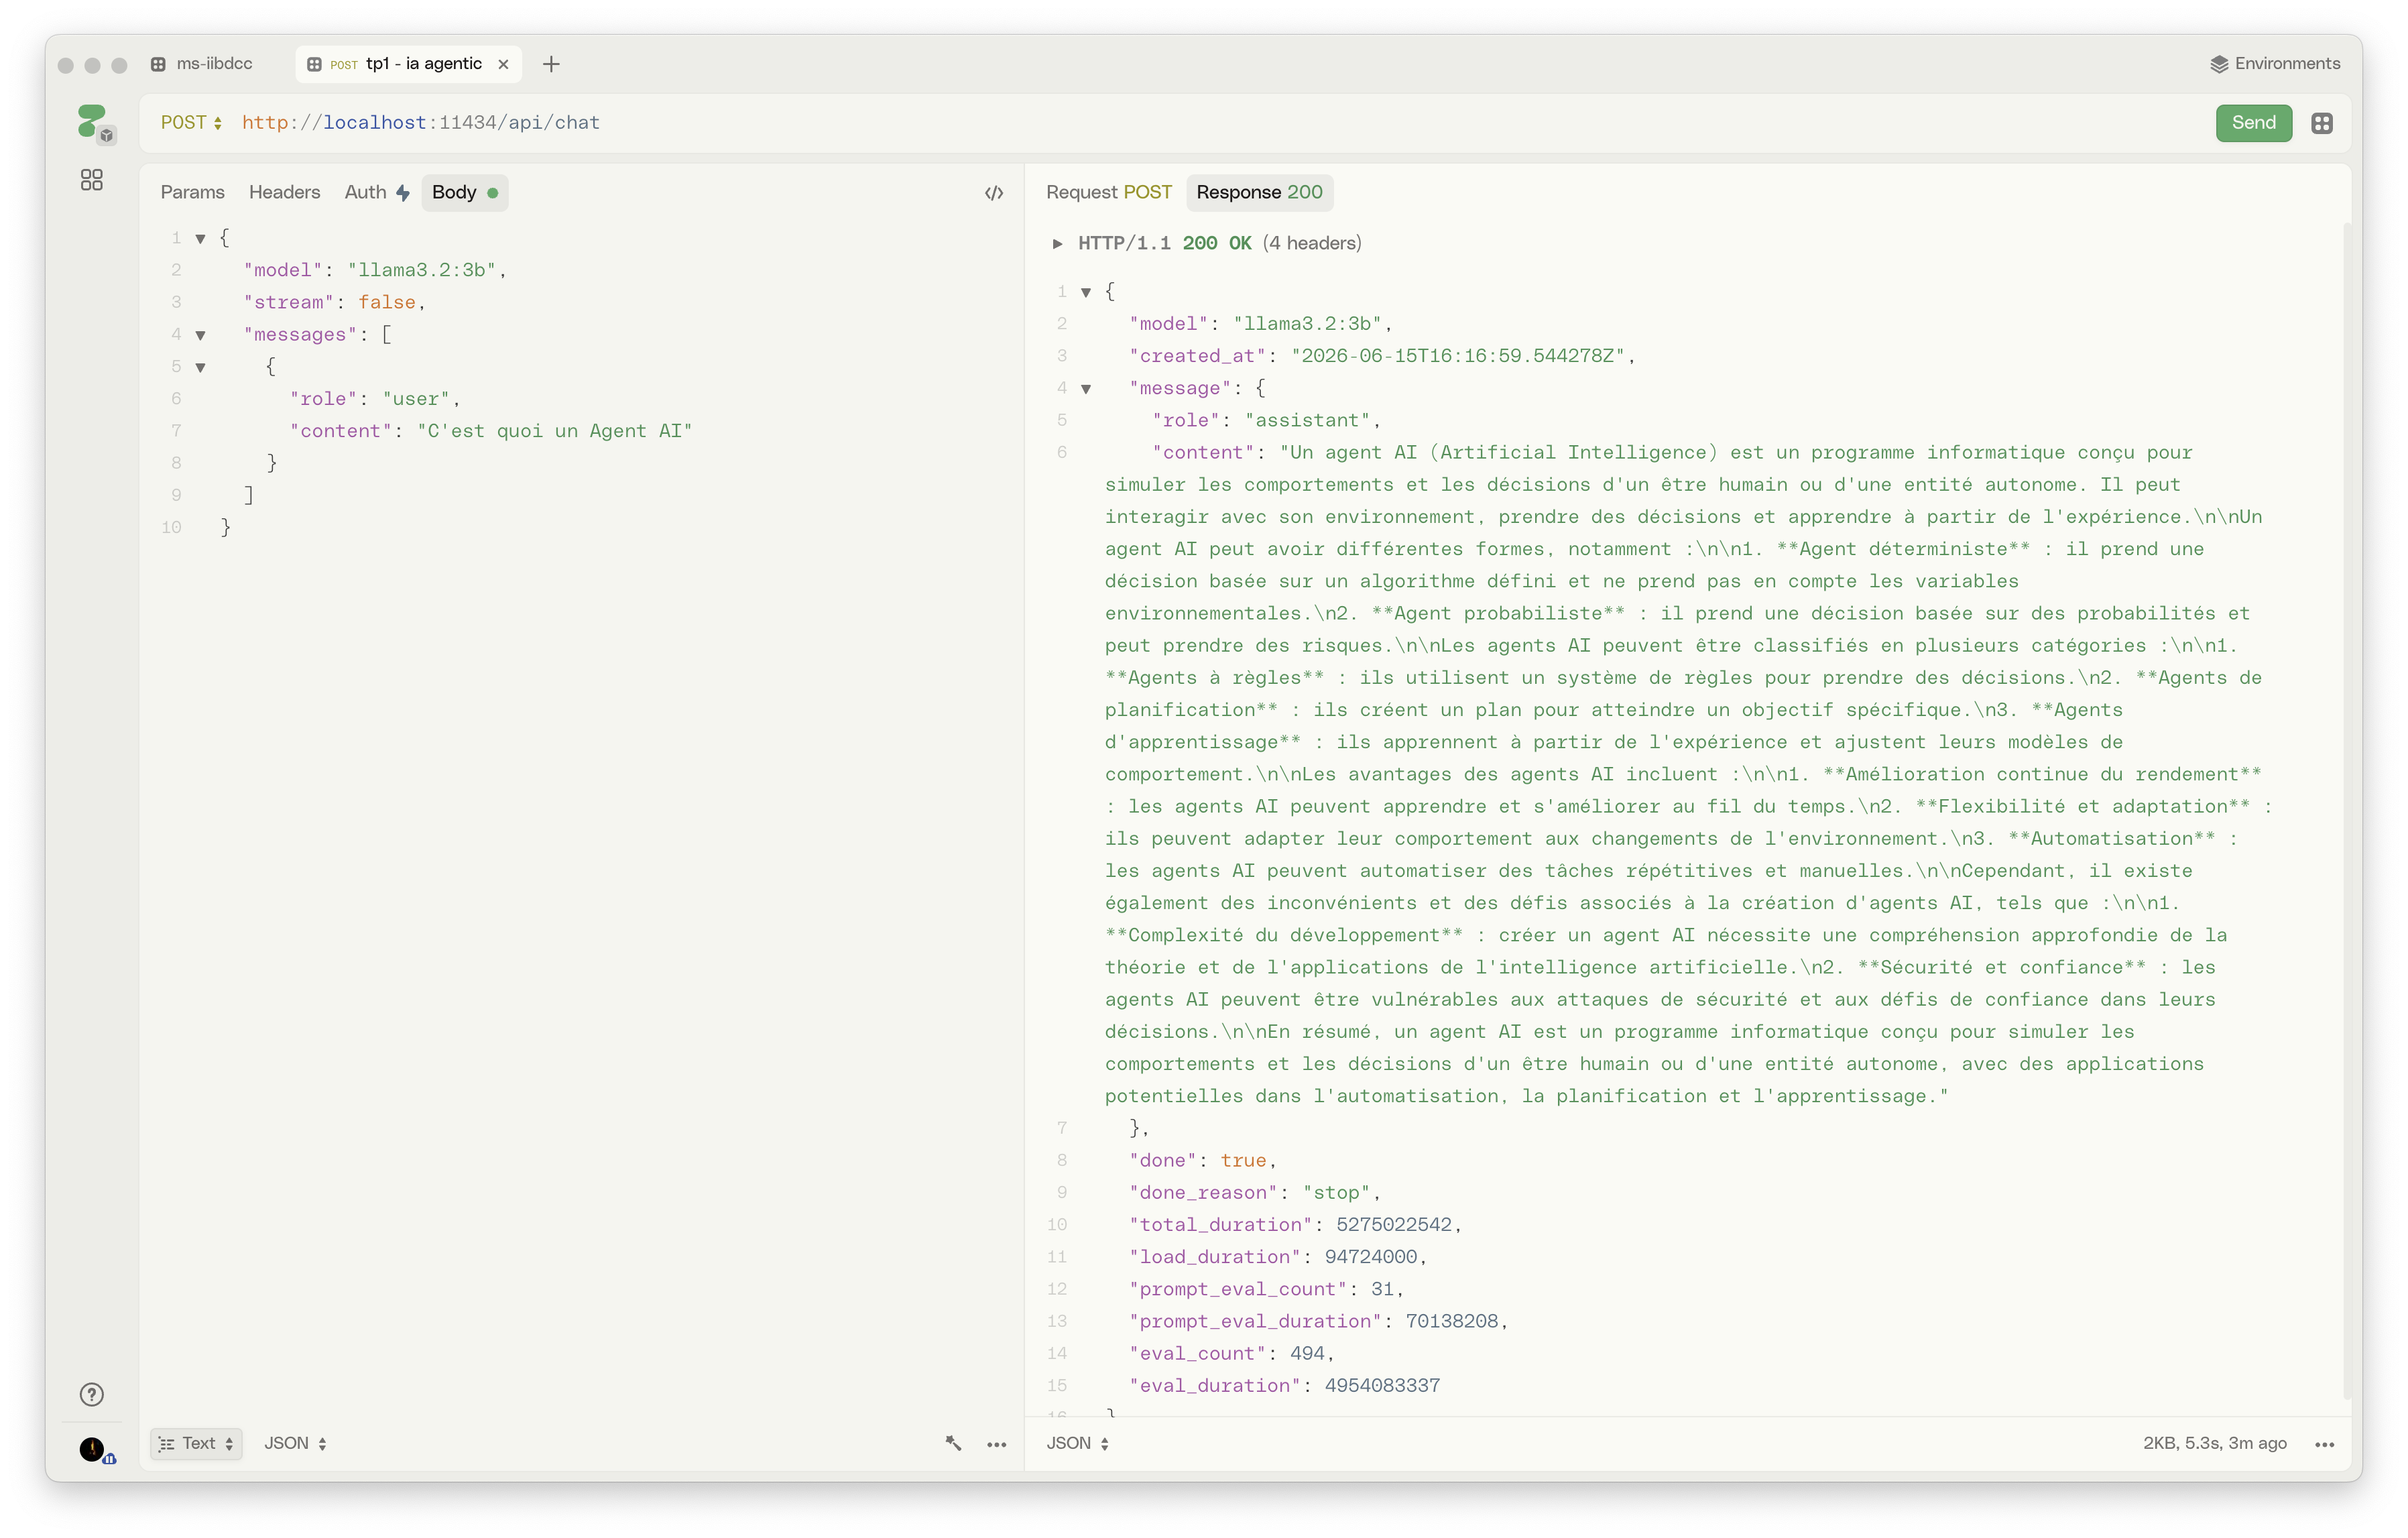

In [ ]:
import base64
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage
from IPython.display import display, Markdown, Image

# Set uniform image path parameters matching the project resources verbatim
path = "rag.png"
display(Image(path))

# Base64 encoder helper function
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# Convert local asset to string payload
img = encode_image(path)

llm5 = ChatOpenAI(model="gpt-5.2")

# Query the vision model with mixed multi-modal list parameters
resp5 = llm5.invoke(input=[
    HumanMessage(content=[
        {"type": "text", "text": "Qu'est ce que tu vois dans cette image"},
        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img}"}}
    ])
])

print(display(Markdown(resp5.content)))